# Estimation module: quick tour

`pysatl_core.estimation` fits a **family** of distributions to a sample by maximum
likelihood: `family.fit(sample)` returns an `MLEResult` with the estimated parameters,
the attained log-likelihood, a convergence flag, and everything needed to compare fits
or build the resulting distribution.

This notebook is a short tour of *what you can do with it*, not of the math behind it —
for the derivations and log-likelihood surfaces, see `example_mle.ipynb`.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from pysatl_core.estimation import FitDataError, InsufficientDataError
from pysatl_core.families.configuration import configure_families_register
from pysatl_core.types import FamilyName

registry = configure_families_register()
Normal = registry.get(FamilyName.NORMAL)
Gamma = registry.get(FamilyName.GAMMA)
Exponential = registry.get(FamilyName.EXPONENTIAL)
Uniform = registry.get(FamilyName.CONTINUOUS_UNIFORM)

rng = np.random.default_rng(42)
plt.rcParams.update({"figure.figsize": (8.5, 3.4), "figure.dpi": 110, "axes.grid": True,
                      "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})


## 1. The basic call: `family.fit(sample)`

No setup, no starting values, no method to pick — `fit` figures out the fastest route on
its own (closed form when the family has one, a numerical search otherwise).


In [2]:
sample = rng.normal(loc=2.0, scale=1.5, size=500)
result = Normal.fit(sample)

print(f"mu={result.params.mu:.4f}  sigma={result.params.sigma:.4f}  "
      f"(log-likelihood={result.log_likelihood:.2f}, success={result.success})")


mu=1.9803  sigma=1.4385  (log-likelihood=-891.26, success=True)


## 2. The result is a rich object, not a bare tuple

Everything a caller needs to judge the fit is a named field — no need to remember
positional order or wonder whether "0.98" is the estimate or the p-value.


In [3]:
print("estimated parameters   ", dict(result.params.parameters))
print("log-likelihood         ", result.log_likelihood)
print("converged?             ", result.success)
print("route taken            ", result.method, f"(optimizer={result.optimizer!r})")
print("free parameters        ", result.n_params, "out of", result.n_observations, "observations")
print("AIC / BIC              ", round(result.aic, 2), "/", round(result.bic, 2))
print("message                ", result.message or "(nothing to report)")


estimated parameters    {'mu': 1.9803107742995991, 'sigma': 1.4384605570750455}
log-likelihood          -891.2560086780747
converged?              True
route taken             closed_form (optimizer=None)
free parameters         2 out of 500 observations
AIC / BIC               1786.51 / 1794.94
message                 closed-form maximum likelihood solution


## 3. `.distribution`: turn the estimate back into a distribution

The fitted parameters are only half the story — `result.distribution` builds the actual
`ParametricFamilyDistribution` on demand, so you can immediately compute a pdf, a cdf, or
draw new samples from it.


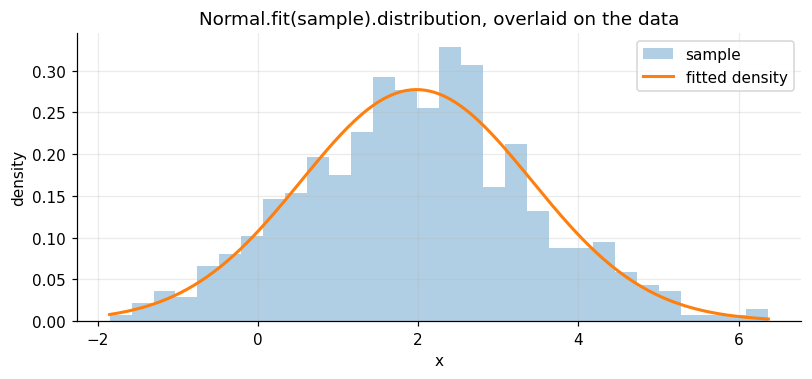

In [4]:
fitted = result.distribution
grid = np.linspace(sample.min(), sample.max(), 300)

fig, ax = plt.subplots()
ax.hist(sample, bins=30, density=True, alpha=0.35, label="sample")
ax.plot(grid, fitted.calculate_characteristic("pdf", grid), lw=2, label="fitted density")
ax.set(xlabel="x", ylabel="density", title="Normal.fit(sample).distribution, overlaid on the data")
ax.legend()
plt.show()


## 4. Fixing parameters with `.view()`

Know one of the parameters already? `family.view(name=value)` pins it and fits only the
rest — no separate "fa=" / "floc=" argument to remember, `fit` works the same way on the
view as on the family itself.


In [5]:
centred_sample = rng.normal(loc=0.0, scale=3.0, size=400)

free_fit = Normal.fit(centred_sample)
pinned_fit = Normal.view(mu=0.0).fit(centred_sample)   # mu is known to be 0 here

print(f"free fit:    mu={free_fit.params.mu:.3f}  sigma={free_fit.params.sigma:.3f}  "
      f"({free_fit.n_params} free params, AIC={free_fit.aic:.1f})")
print(f"pinned fit:  sigma={pinned_fit.params.sigma:.3f}  "
      f"({pinned_fit.n_params} free param,  AIC={pinned_fit.aic:.1f})")


free fit:    mu=-0.247  sigma=3.057  (2 free params, AIC=2033.1)
pinned fit:  sigma=3.067  (1 free param,  AIC=2033.7)


Pinning a parameter you actually know reduces `n_params` by one and — because AIC/BIC
charge for every estimated parameter — tends to lower AIC too, on top of being a more
honest description of what was actually estimated.


## 5. Choosing the optimizer explicitly

`fit` normally picks the route for you, but passing `optimizer=` forces the numerical
search even for a family that has a closed-form formula — useful for cross-checking, or
for trying a more robust method on awkward data. It says so with a warning, rather than
silently ignoring the closed form the way SciPy's `rv_continuous.fit` does.


In [6]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    numeric_fit = Normal.fit(sample, optimizer="Nelder-Mead")

print(f"closed form : mu={result.params.mu:.6f}  sigma={result.params.sigma:.6f}")
print(f"Nelder-Mead : mu={numeric_fit.params.mu:.6f}  sigma={numeric_fit.params.sigma:.6f}")
print(f"took {numeric_fit.n_iterations} iterations, {numeric_fit.n_function_evaluations} "
      f"objective evaluations to land within {abs(numeric_fit.params.sigma - result.params.sigma):.2e} "
      f"of the exact answer")
print("warning raised:", str(caught[0].message)[:88] + "...")


closed form : mu=1.980311  sigma=1.438461
Nelder-Mead : mu=1.980311  sigma=1.438461
took 22 iterations, 45 objective evaluations to land within 0.00e+00 of the exact answer
warning raised: family 'Normal' has a closed-form MLE, but 'optimizer=Nelder-Mead' was passed, so the nu...


## 6. Comparing families on the same data with AIC/BIC

`fit` works identically across families, which makes model selection a small loop: fit
every candidate, and let AIC (or BIC, if you want to penalise complexity harder) pick the
winner.


In [7]:
positive_sample = rng.gamma(shape=2.5, scale=1.7, size=600)

candidates = {"Gamma": Gamma, "Exponential": Exponential}
fits = {name: family.fit(positive_sample) for name, family in candidates.items()}

for name, fit in sorted(fits.items(), key=lambda kv: kv[1].aic):
    print(f"{name:<12} AIC={fit.aic:8.2f}   BIC={fit.bic:8.2f}   "
          f"params={dict(fit.params.parameters)}")

best = min(fits, key=lambda name: fits[name].aic)
print(f"\nlower AIC wins: {best} fits these (genuinely gamma-distributed) data better")


Gamma        AIC= 2680.13   BIC= 2688.93   params={'k': 2.4687812284203337, 'theta': 1.6627719689931122}
Exponential  AIC= 2896.65   BIC= 2901.05   params={'lambda_': 0.2436041917805894}

lower AIC wins: Gamma fits these (genuinely gamma-distributed) data better


## 7. Errors you can actually catch

A fit that merely fails to *converge* is reported through `result.success`, not raised.
Exceptions are reserved for situations no optimizer could recover from: too little data,
or data a family's fixed support can never explain.


In [8]:
try:
    Normal.fit([1.0])   # 1 observation, 2 parameters to estimate
except InsufficientDataError as exc:
    print("InsufficientDataError:", exc)

try:
    Gamma.fit([-2.0, 1.0, 2.0, 3.0])   # Gamma's support is [0, inf) -- fixed, not movable
except FitDataError as exc:
    print("FitDataError:         ", exc)


InsufficientDataError: Family 'Normal' estimates 2 free parameter(s) (mu, sigma), but the sample holds 1 observation(s). At least 2 are required; with fewer, the likelihood has no isolated maximum.
FitDataError:          1 of 4 observation(s) lie outside the support ContinuousSupport(left=0.0, right=inf, left_closed=True, right_closed=False) of family 'Gamma', which does not depend on its parameters — for example -2.0. No parameter value can give those points a positive density, so the likelihood is zero everywhere and there is nothing to maximise. Drop them, or fit a family whose support covers the data.


## Cheat sheet

| want to... | do this |
|---|---|
| fit a family to data | `family.fit(sample)` |
| read off a parameter | `result.params.<name>` |
| get the distribution back | `result.distribution` |
| compare fits | `result.aic`, `result.bic` |
| check it actually converged | `result.success`, `result.message` |
| fix a known parameter | `family.view(name=value).fit(sample)` |
| force a numerical search | `family.fit(sample, optimizer="Nelder-Mead", ...)` |
| catch unrecoverable input | `except (InsufficientDataError, FitDataError)` |
